In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import util.functions as functions
from models.FNO import CAPE_FNO
import pybamm
import flax

In [2]:
from skopt.utils import use_named_args
from skopt.space import Real
from skopt import gp_minimize

In [3]:
from util.FNO_util import preprocess_data, train_test_split, remove_padding, normalise_diffusion
# from util.plotting import create_plot_FNO_results, create_plot_voltage
from util.postprocess import filter_anode_cathode, calc_error_metrics, calc_error_metrics_all
from inference.parameter_estimation import get_jnp_U_OCP_anode, get_jnp_U_OCP_cathode

In [4]:
family = "GRF"
N_total = 33000
data = np.load(f"../data/{family}_{N_total}.npz")
split_seed = 42
test_ratio = 0.1

In [5]:
parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)
U_OCP_an = get_jnp_U_OCP_anode(parameter_name)
U_OCP_ca = get_jnp_U_OCP_cathode(parameter_name)


C = params_bat["Nominal cell capacity [A.h]"]
Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
Dca = params_bat["Positive particle diffusivity [m2.s-1]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
epsan = params_bat["Negative electrode active material volume fraction"]
epsca = params_bat["Positive electrode active material volume fraction"]
cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
Lan = params_bat["Negative electrode thickness [m]"]
Lca = params_bat["Positive electrode thickness [m]"]
A = params_bat["Electrode height [m]"] * params_bat["Electrode width [m]"]

EPS = 1e-6
t_max = 3600

In [6]:
train_data, test_data = train_test_split(data, N_total=N_total, test_ratio=test_ratio, seed=split_seed)  # noqa: F405

In [7]:
func_I = np.array(test_data["current"])

### Anode data ###
cn_anode = np.array(test_data["cn_anode"])
c0_anode = np.array(test_data["c0_anode"])
D_anode = np.array(test_data["Dan"])

### Cathode data ###
cn_cathode = np.array(test_data["cn_cathode"])
c0_cathode = np.array(test_data["c0_cathode"])
D_cathode = np.array(test_data["Dca"])

socs = np.array(test_data["soc"])

In [8]:
D_anode = normalise_diffusion(D_anode)
D_cathode = normalise_diffusion(D_cathode)

In [9]:
parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)
cs_max_a_norm = 1 #params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c_norm = 1 #params_bat["Maximum concentration in positive electrode [mol.m-3]"]
cs_min_a_norm = 0.0
cs_min_c_norm = 0.0

In [10]:
cn_anode, cn_cathode, mask = filter_anode_cathode(cn_anode, cn_cathode,
                                                    anode_lo=cs_min_a_norm, anode_hi=cs_max_a_norm, 
                                                    cathode_lo=cs_min_c_norm, cathode_hi=cs_max_c_norm)

In [11]:
func_I = func_I[mask]
c0_anode = c0_anode[mask]
c0_cathode = c0_cathode[mask]
D_anode = D_anode[mask]
D_cathode = D_cathode[mask]
socs = socs[mask]

In [12]:
# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

In [13]:
X_anode, Y_anode = preprocess_data(func_I, c0_anode, cn_anode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_cathode, Y_cathode = preprocess_data(func_I, c0_cathode, cn_cathode, num_samples_I, num_samples_c0, padding_r, padding_t)

In [14]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 8
hidden_channels = 64
input_channels = 4 # We should automate this TODO
output_channels = 1
cape_hidden_size = 32

In [15]:
N_test = func_I.shape[0]
rng = np.random.default_rng(split_seed)
test_idx = 8 #rng.integers(0, N_test)

In [16]:
model = CAPE_FNO(k_modes=k_modes, input_channels= input_channels, 
                 fno_depth=fno_depth, cape_hidden_size = cape_hidden_size, 
                 hidden_channels=hidden_channels, output_channels=output_channels)

main_key = jax.random.PRNGKey(split_seed)
# Initialize parameters
dummy_D = jax.random.normal(main_key, (1,1))
params = model.init(main_key, X_anode[:1,...], dummy_D)

# Forward pass
out = model.apply(params, X_anode[:1,...], dummy_D)

In [17]:
anode_file = "../trained_models/cape_fno/anode_GRF_2025-06-03_17-11-44.msgpack"
cathode_file = "../trained_models/cape_fno/cathode_GRF_2025-06-03_17-35-54.msgpack"

params_anode = functions.load_model_params(anode_file)
params_cathode = functions.load_model_params(cathode_file)

params_anode = flax.serialization.from_bytes(params, params_anode)
params_cathode = flax.serialization.from_bytes(params, params_cathode)

In [18]:
LOG10_D_MIN, LOG10_D_MAX = -15.0, -12.0

In [19]:
R_gas = params_bat['Ideal gas constant [J.K-1.mol-1]']
F = params_bat['Faraday constant [C.mol-1]']
Temp = params_bat["Ambient temperature [K]"]

In [20]:
V_pred_list = []
c_an_surf_list = []
c_ca_surf_list = []

In [21]:
def calc_voltage(params_bat, c_an_surf, c_ca_surf, func_I,):
    # Calculate the anode and cathode OCPs
    c_an_surf = jnp.clip(c_an_surf, EPS, 1-EPS)
    c_ca_surf = jnp.clip(c_ca_surf, EPS, 1-EPS)

    j_anode   = jnp.sqrt(c_an_surf * (1.0 - c_an_surf))
    j_cathode = jnp.sqrt(c_ca_surf * (1.0 - c_ca_surf))

    xan = functions.in_arcsinh(-func_I, Ran, epsan, Lan, A)
    xca = functions.in_arcsinh(-func_I, Rca, epsca, Lca, A)

    V_pred = U_OCP_ca(c_ca_surf) - U_OCP_an(c_an_surf) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xan/(j_anode)) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xca/(j_cathode))

    return V_pred

In [22]:
kan = Ran / (3 * epsan * Lan * A)
kca = Rca / (3 * epsca * Lca * A)
RTF = 2 * R_gas*Temp/F

In [23]:
def inference_concentration_norm(X_anode_truth, X_cathode_truth, D_anode_candidate, D_cathode_candidate):
    
    cn_anode = model.apply(params_anode,X_anode_truth, D_anode_candidate)
    cn_cathode = model.apply(params_cathode,X_cathode_truth, D_cathode_candidate)

    cn_anode_reshape = remove_padding(cn_anode, padding_r = padding_r, padding_t = padding_t)
    cn_cathode_reshape = remove_padding(cn_cathode, padding_r = padding_r, padding_t = padding_t)

    return cn_anode_reshape, cn_cathode_reshape

In [24]:
@jax.jit
def inference_step(func_I_truth, X_anode_truth, X_cathode_truth, D_anode_candidate, D_cathode_candidate):
    cn_anode = model.apply(params_anode,X_anode_truth, D_anode_candidate)
    cn_cathode = model.apply(params_cathode,X_cathode_truth, D_cathode_candidate)

    cn_anode_reshape = remove_padding(cn_anode, padding_r = padding_r, padding_t = padding_t)
    cn_cathode_reshape = remove_padding(cn_cathode, padding_r = padding_r, padding_t = padding_t)

    cn_anode_surf = cn_anode_reshape[:, -1, :, 0].clip(EPS, 1.0 - EPS)
    cn_cathode_surf = cn_cathode_reshape[:, -1, :, 0].clip(EPS, 1.0 - EPS)

    j_anode   = jnp.sqrt(cn_anode_surf * (1.0 - cn_anode_surf))
    j_cathode = jnp.sqrt(cn_cathode_surf * (1.0 - cn_cathode_surf))

    xan = -func_I_truth * kan
    xca = -func_I_truth * kca

    V_pred = U_OCP_ca(cn_cathode_surf) - U_OCP_an(cn_anode_surf) - RTF * jnp.arcsinh(0.5*xan/(j_anode)) - RTF * jnp.arcsinh(0.5*xca/(j_cathode))
    return V_pred

In [25]:
# ---- design space ----------------------------------------
dimensions = [
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dan"),
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dca"),
]

In [26]:
V_data = functions.post_proc_true(params_bat, func_I[test_idx], cn_anode[test_idx,-1,:], cn_cathode[test_idx,-1,:], Ran, Rca, epsan, epsca, Lan, Lca, A)
assert np.isfinite(V_data).all()

In [27]:
@jax.jit
def calc_rmse(V_pred, V_data):
    rmse = jnp.sqrt(jnp.mean((V_pred - V_data) ** 2))
    return rmse

@jax.jit
def calc_rel_ls(V_pred, V_data):
    rel_l2 = jnp.sqrt(jnp.mean((V_pred - V_data) ** 2)) / jnp.sqrt(jnp.mean(V_data ** 2))
    return rel_l2

In [28]:
normalise_diffusion = jax.jit(normalise_diffusion)

In [29]:
@use_named_args(dimensions)
def obj_voltage(log10_Dan, log10_Dca):
    # --- 1.  normalise the candidate diffusivities ------------
    log10_Dan_norm = normalise_diffusion(jnp.array(log10_Dan).reshape(-1,1))
    log10_Dca_norm = normalise_diffusion(jnp.array(log10_Dca).reshape(-1,1))
    # --- 2.  CAPE-FNO predictions of c(r,t) ---------------
    V_pred = inference_step(func_I[test_idx],
        X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
        log10_Dan_norm, log10_Dca_norm
    )
    #V_pred_list.append(V_pred)

    # --- 4.  voltage RMSE (you can use MAE or any other scalar) -------------
    rmse = calc_rel_ls(V_pred, V_data)
    
    return float(rmse)

In [30]:
res = gp_minimize(
    obj_voltage,
    dimensions=dimensions,
    n_calls=60,            # ±25–35 evaluations per dimension is usually plenty
    n_initial_points=12,   # random Sobol/Bach search first
    acq_func="EI",         # expected improvement
    random_state=0,
)

best_log10_Dan, best_log10_Dca = res.x
print(f"Best log10(Dan) = {best_log10_Dan:.3f}")
print(f"Best log10(Dca) = {best_log10_Dca:.3f}")
print(f"Voltage-curve RMSE = {res.fun:.4e}")

Best log10(Dan) = -14.663
Best log10(Dca) = -12.170
Voltage-curve RMSE = 1.8789e-04


In [31]:
res.func_vals

array([0.00554569, 0.00567615, 0.00558482, 0.00407914, 0.00371469,
       0.00566782, 0.00497059, 0.00456315, 0.00480934, 0.00078308,
       0.00530726, 0.00542652, 0.01746717, 0.00569494, 0.00563766,
       0.00100727, 0.00568786, 0.00225015, 0.00364204, 0.00125007,
       0.00565369, 0.00555891, 0.00561626, 0.00568198, 0.00154274,
       0.00569454, 0.00517314, 0.00303096, 0.00569136, 0.00560386,
       0.00569671, 0.01413764, 0.00503346, 0.00018789, 0.00569666,
       0.00089452, 0.00548795, 0.00301329, 0.00566001, 0.00536792,
       0.00568642, 0.00563   , 0.00567326, 0.00564564, 0.0043405 ,
       0.00567924, 0.00524694, 0.00340303, 0.00551306, 0.00262869,
       0.00045203, 0.00189967, 0.01742332, 0.00545699, 0.0056902 ,
       0.00469652, 0.00566945, 0.00564518, 0.00568724, 0.00468686])

In [31]:
V_best_cape_fno_from_cape_fno = inference_step(func_I[test_idx],
    X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
    normalise_diffusion(jnp.array(best_log10_Dan).reshape(-1,1)), normalise_diffusion(jnp.array(best_log10_Dca).reshape(-1,1))
)
# print(f"Best voltage prediction: {V_best}")

In [32]:
log_Dan_true = float(D_anode[test_idx])
log_Dca_true = float(D_cathode[test_idx])

In [33]:
def unnormalise_diffusion(log10_D):
    return (log10_D +1)/2*(LOG10_D_MAX-LOG10_D_MIN) + LOG10_D_MIN

In [34]:
log_Dan_true = unnormalise_diffusion(log_Dan_true)
log_Dca_true = unnormalise_diffusion(log_Dca_true)

In [35]:
V_test_pred = inference_step(func_I[test_idx],
    X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
    D_anode[test_idx][None, ...].reshape(-1,1), D_cathode[test_idx][None, ...].reshape(-1,1)
)

assert np.isclose(V_test_pred, V_data, rtol=1).all(), "Test prediction does not match the data!"

In [36]:
# ---- design space ----------------------------------------
dimensions_pybamm = [
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dan_pybamm"),
    Real(LOG10_D_MIN, LOG10_D_MAX, name="log10_Dca_pybamm"),
]

In [37]:
import pybamm
import numpy as np

# ▶  a baseline Li-ion model  (SPMe is fast; swap for DFN if you prefer)
pybamm_model = pybamm.lithium_ion.SPM()
pybamm_model.events = []

# ▶  time grid that matches your measured voltage trace V_true
t_eval = np.linspace(0, 3600, 75)   # dt = sample spacing [s]

# ▶  current profile: use your measured current array `func_I`
#     (shape (T,)).  Convert to an interpolant so PyBaMM can call it at any t.
current_fun = pybamm.Interpolant(t_eval, -func_I[test_idx].squeeze(), pybamm.t)

#     Tell the model to use that function instead of the built-in C-rate
params_bat["Current function [A]"] = current_fun

In [38]:
@use_named_args(dimensions_pybamm)
def obj_voltage_pybamm(log10_Dan_pybamm, log10_Dca_pybamm):

    # --- 1.  normalise the candidate diffusivities ------------
    D_anode_candidate = 10 ** log10_Dan_pybamm
    D_cathode_candidate = 10 ** log10_Dca_pybamm

    params_bat["Negative particle diffusivity [m2.s-1]"] = D_anode_candidate
    params_bat["Positive particle diffusivity [m2.s-1]"] = D_cathode_candidate

    sim = pybamm.Simulation(pybamm_model, parameter_values=params_bat)
    sim.solve(initial_soc = socs[test_idx], t_eval=t_eval)

    #V_pred = sim.solution["Terminal voltage [V]"](t_eval)

    c_an_surf = sim.solution["Negative particle concentration"].entries[-1,0, :]

    c_ca_surf = sim.solution["Positive particle concentration"].entries[-1,0, :]
    # --- 3.  voltage RMSE (you can use MAE or any other scalar) -------------
    V_pred = calc_voltage(params_bat, c_an_surf, c_ca_surf, func_I[test_idx])
    rmse = jnp.sqrt(jnp.mean((V_pred - V_data) ** 2))
    return float(rmse)


In [39]:
res_pybamm = gp_minimize(
    obj_voltage_pybamm,
    dimensions=dimensions_pybamm,
    n_calls=60,            # ±25–35 evaluations per dimension is usually plenty
    n_initial_points=12,   # random Sobol/Bach search first
    acq_func="EI",         # expected improvement
    random_state=0,
)

best_log10_Dan_pybamm, best_log10_Dca_pybamm = res_pybamm.x
print(f"Best log10(Dan) = {best_log10_Dan_pybamm:.3f}")
print(f"Best log10(Dca) = {best_log10_Dca_pybamm:.3f}")
print(f"Voltage-curve RMSE = {res_pybamm.fun:.4e}")

Best log10(Dan) = -14.674
Best log10(Dca) = -14.967
Voltage-curve RMSE = 2.4287e-05


In [ ]:
res_pybamm.func_vals

In [40]:
# Best log10(Dan) = -14.801
# Best log10(Dca) = -14.985

In [41]:
params_bat["Negative particle diffusivity [m2.s-1]"] = 10 ** best_log10_Dan
params_bat["Positive particle diffusivity [m2.s-1]"] = 10 ** best_log10_Dca

sim = pybamm.Simulation(model=pybamm_model, parameter_values=params_bat)
sim.solve(initial_soc = socs[test_idx], t_eval=t_eval)

c_an_pybamm_from_cape_fno = sim.solution["Negative particle concentration"].entries
c_ca_pybamm_from_cape_fno = sim.solution["Positive particle concentration"].entries

c_an_surf_pybamm_from_cape_fno = c_an_pybamm_from_cape_fno[-1, 0, :]
c_ca_surf_pybamm_from_cape_fno = c_ca_pybamm_from_cape_fno[-1, 0, :]

# V_best_pybamm_from_cape_fno = sim.solution["Local voltage [V]"](t_eval)
V_best_pybamm_from_cape_fno = calc_voltage(params_bat, c_an_surf_pybamm_from_cape_fno, c_ca_surf_pybamm_from_cape_fno, func_I[test_idx])


params_bat["Negative particle diffusivity [m2.s-1]"] = 10 ** log_Dan_true
params_bat["Positive particle diffusivity [m2.s-1]"] = 10 ** log_Dca_true

sim = pybamm.Simulation(model=pybamm_model, parameter_values=params_bat)
sim.solve(initial_soc = socs[test_idx], t_eval=t_eval)

c_an_true_pybamm = sim.solution["Negative particle concentration"].entries
c_ca_true_pybamm = sim.solution["Positive particle concentration"].entries

c_an_surf_true_pybamm = c_an_true_pybamm[-1, 0, :]
c_ca_surf_true_pybamm = c_ca_true_pybamm[-1, 0, :]

# V_true_pybamm = sim.solution["Local voltage [V]"](t_eval)
V_true_pybamm = calc_voltage(params_bat, c_an_surf_true_pybamm, c_ca_surf_true_pybamm, func_I[test_idx])


params_bat["Negative particle diffusivity [m2.s-1]"] = 10 ** best_log10_Dan_pybamm
params_bat["Positive particle diffusivity [m2.s-1]"] = 10 ** best_log10_Dca_pybamm

sim = pybamm.Simulation(model=pybamm_model, parameter_values=params_bat)
sim.solve(initial_soc = socs[test_idx], t_eval=t_eval)
# V_best_pybamm_from_pybamm = sim.solution["Local voltage [V]"](t_eval)

c_an_pybamm_from_pybamm = sim.solution["Negative particle concentration"].entries
c_ca_pybamm_from_pybamm = sim.solution["Positive particle concentration"].entries

c_an_surf_pybamm_from_pybamm = c_an_pybamm_from_pybamm[-1, 0, :]
c_ca_surf_pybamm_from_pybamm = c_ca_pybamm_from_pybamm[-1, 0, :]

V_best_pybamm_from_pybamm = calc_voltage(params_bat, c_an_surf_pybamm_from_pybamm, c_ca_surf_pybamm_from_pybamm, func_I[test_idx])


In [42]:
V_best_cape_fno_from_pybamm = inference_step(func_I[test_idx],
    X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
    normalise_diffusion(jnp.array(best_log10_Dan_pybamm).reshape(-1,1)),
    normalise_diffusion(jnp.array(best_log10_Dca_pybamm).reshape(-1,1))
)

In [43]:
import matplotlib.pyplot as plt

In [44]:
V_best_cape_fno_from_cape_fno

Array([[3.3282945, 3.327615 , 3.326739 , 3.3262959, 3.3275766, 3.3321128,
        3.3401306, 3.348475 , 3.353733 , 3.356396 , 3.356952 , 3.3565667,
        3.3552873, 3.353466 , 3.3509223, 3.347864 , 3.3441703, 3.3396413,
        3.334516 , 3.3289201, 3.3227973, 3.31645  , 3.309569 , 3.302473 ,
        3.2941737, 3.2839305, 3.27224  , 3.2612514, 3.253428 , 3.2487216,
        3.246371 , 3.245791 , 3.2460535, 3.2471845, 3.2484894, 3.2500107,
        3.2512765, 3.25208  , 3.2527254, 3.2527282, 3.2526128, 3.2524605,
        3.2523277, 3.2528286, 3.2538452, 3.2554116, 3.2579904, 3.2609828,
        3.2647636, 3.2690148, 3.2735124, 3.2779768, 3.282464 , 3.2867744,
        3.291072 , 3.295356 , 3.3001747, 3.3067677, 3.3168643, 3.3307176,
        3.34472  , 3.3553224, 3.3623822, 3.36763  , 3.3722587, 3.376481 ,
        3.3805783, 3.3844469, 3.3881998, 3.3920214, 3.3955882, 3.39903  ,
        3.4022098, 3.4060755, 3.4108312]], dtype=float32)

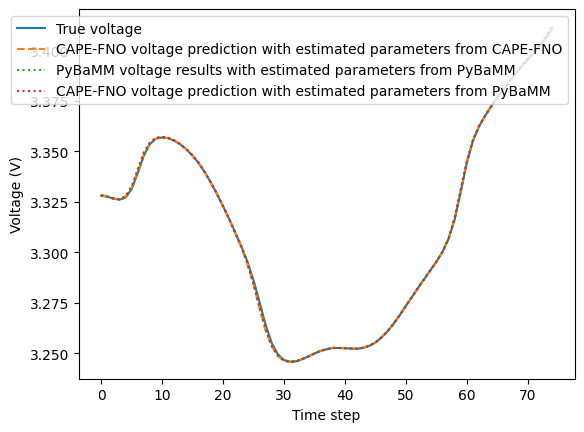

In [45]:
plt.plot(V_data, label="True voltage")
# plt.plot(V_true_pybamm, label="PyBaMM voltage results with original test sample diffusivities")

plt.plot(V_best_cape_fno_from_cape_fno.flatten(), label="CAPE-FNO voltage prediction with estimated parameters from CAPE-FNO", linestyle='--')
# plt.plot(V_best_pybamm_from_cape_fno.reshape(-1,1), label="PyBaMM voltage results with estimated parameters from CAPE-FNO", linestyle='--')


plt.plot(V_best_pybamm_from_pybamm.reshape(-1,1), label="PyBaMM voltage results with estimated parameters from PyBaMM", linestyle=':')
plt.plot(V_best_cape_fno_from_pybamm.reshape(-1,1), label="CAPE-FNO voltage prediction with estimated parameters from PyBaMM", linestyle=':')

plt.xlabel("Time step")
plt.ylabel("Voltage (V)")
plt.legend()
plt.show()

In [46]:
mean_error = (np.abs(best_log10_Dan - log_Dan_true) + np.abs(best_log10_Dca - log_Dca_true))/2

In [47]:
mean_error_pybamm = (np.abs(best_log10_Dan_pybamm - log_Dan_true) + np.abs(best_log10_Dca_pybamm - log_Dca_true))/2

In [48]:
mean_error

np.float64(0.20979023200082558)

In [49]:
mean_error_pybamm

np.float64(1.1952944077034457)

In [50]:
#error Vdata_Vpred , conc_anode_data_vs_pred, conc_cathode_data_vs_pred all for the best parameters for both CAPE-FNO and PyBaMM

In [51]:
V_max = params_bat["Upper voltage cut-off [V]"]
V_min = params_bat["Lower voltage cut-off [V]"]

V_best_cape_fno_from_cape_fno_norm = (V_best_cape_fno_from_cape_fno - V_min) / (V_max - V_min)
V_best_pybamm_from_cape_fno_norm = (V_best_pybamm_from_cape_fno - V_min) / (V_max - V_min)
V_best_pybamm_from_pybamm_norm = (V_best_pybamm_from_pybamm - V_min) / (V_max - V_min)
V_true_pybamm_norm = (V_true_pybamm - V_min) / (V_max - V_min)
V_best_cape_fno_from_pybamm_norm = (V_best_cape_fno_from_pybamm - V_min) / (V_max - V_min)
V_data_norm = (V_data - V_min) / (V_max - V_min)


In [52]:
# concentration_errors_anode = calc_error_metrics(c_test_pred_scaled_anode, c_test_true_scaled_anode)
# concentration_errors_cathode = calc_error_metrics(c_test_pred_scaled_cathode, c_test_true_scaled_cathode)
# concentration_errors_all = calc_error_metrics_all(concentration_errors_anode, concentration_errors_cathode)
voltage_errors_cape_fno = calc_error_metrics(V_best_cape_fno_from_cape_fno, V_data, axis=(0,))
voltage_errors_pybamm_from_cape_fno = calc_error_metrics(V_best_pybamm_from_cape_fno, V_data, axis=(0,))
voltage_errors_pybamm = calc_error_metrics(V_best_pybamm_from_pybamm, V_data, axis=(0,))
voltage_errors_cape_fno_from_pybamm = calc_error_metrics(V_best_cape_fno_from_pybamm, V_data, axis=(0,))

voltage_errors_cape_fno_norm = calc_error_metrics(V_best_cape_fno_from_cape_fno_norm, V_data_norm, axis=(0,))
voltage_errors_pybamm_from_cape_fno_norm = calc_error_metrics(V_best_pybamm_from_cape_fno_norm, V_data_norm, axis=(0,))
voltage_errors_pybamm_norm = calc_error_metrics(V_best_pybamm_from_pybamm_norm, V_data_norm, axis=(0,)) 
voltage_errors_cape_fno_from_pybamm_norm = calc_error_metrics(V_best_cape_fno_from_pybamm_norm, V_data_norm, axis=(0,))


In [53]:
c_an_cape_fno_from_cape_fno, c_ca_cape_fno_from_cape_fno = inference_concentration_norm(
    X_anode[test_idx][None, ...], X_cathode[test_idx][None, ...],
    normalise_diffusion(jnp.array(best_log10_Dan).reshape(-1,1)),
    normalise_diffusion(jnp.array(best_log10_Dca).reshape(-1,1))
    )   

In [54]:
c_an_cape_fno_from_cape_fno.shape

(1, 20, 75, 1)

In [55]:
(np.abs(cn_anode[test_idx, :, :] - c_an_cape_fno_from_cape_fno.squeeze())).mean() * 100

np.float32(0.20637313)

In [ ]:
cn_anode[test_idx, :, :].shape

(20, 75)

: 